#**Advanced concepts in CNN (including hyper parameters tuning)**

> This notebook is part of my learning journey in deep learning fundamentals.
> Focus is on understanding concepts rather than achieving maximum accuracy.

#**Importing Libraries**

In [ ]:
import tensorflow as tf
from keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#**<font color='red'>1.</font> Loading Dataset**

In [ ]:
# Splitting the data into training and testing sets
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt",
    "Sneaker", "Bag", "Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (60000, 28, 28)
y_train.shape: (60000,)
X_test.shape: (10000, 28, 28)
y_test.shape: (10000,)


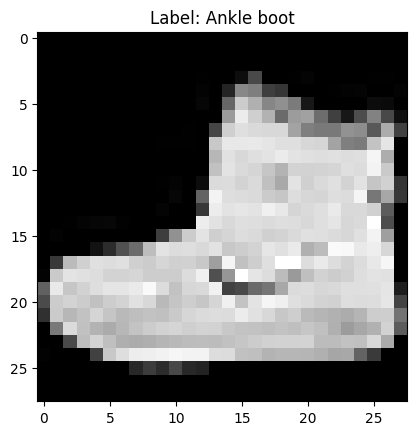

In [ ]:
# Sample image
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {class_names[y_train[0]]}")
plt.show()

#**<font color='red'>2.</font> Pre-processing**

In [ ]:
# Normalizing the data (based on number of possible pixel values)
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
# Adding a new axis as CNN expects image format to have channel count as well (height, width, channels)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print(f"X_train shape : {X_train.shape}")

X_train shape : (60000, 28, 28, 1)


#**<font color='red'>3.</font> Train the baseline CNN model**

In [ ]:
# Define the basic CNN model with its layers
cnn = models.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        86,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,050 (340.04 KB)

 Trainable params: 87,050 (340.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training/fitting the model
# using training datsets
baseline_cnn_training_history = cnn.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8371 - loss: 0.4723 - val_accuracy: 0.8645 - val_loss: 0.3737
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8838 - loss: 0.3293 - val_accuracy: 0.8810 - val_loss: 0.3249
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8978 - loss: 0.2892 - val_accuracy: 0.9012 - val_loss: 0.2824
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9061 - loss: 0.2617 - val_accuracy: 0.8945 - val_loss: 0.2975
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9141 - loss: 0.2388 - val_accuracy: 0.9078 - val_loss: 0.2653


#**<font color='red'>4.</font> Evaluate the baseline CNN model**

In [ ]:
baseline_test_loss, baseline_test_acc = cnn.evaluate(X_test, y_test)
print("Test accuracy:", baseline_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8983 - loss: 0.2849
Test accuracy: 0.8982999920845032


In [ ]:
# Preparing data to plot
def prepare_data_to_plot(training_history, test_accuracy):
  epochs = range(1, len(training_history.history['accuracy']) + 1)
  training_accuracies = [round(accuracy * 100, 3) for accuracy in training_history.history['accuracy']]
  validation_accuracies = [round(accuracy * 100, 3) for accuracy in training_history.history['val_accuracy']]
  test_accuracies = [round(test_accuracy * 100, 3)] * len(epochs)

  data = pd.DataFrame({
      'Epoch': epochs,
      'Training Accuracy': training_accuracies,
      'Validation Accuracy': validation_accuracies,
      'Test Accuracy': test_accuracies
  })

  data = data.melt(id_vars='Epoch', var_name='Dataset', value_name='Accuracy')

  return data, epochs

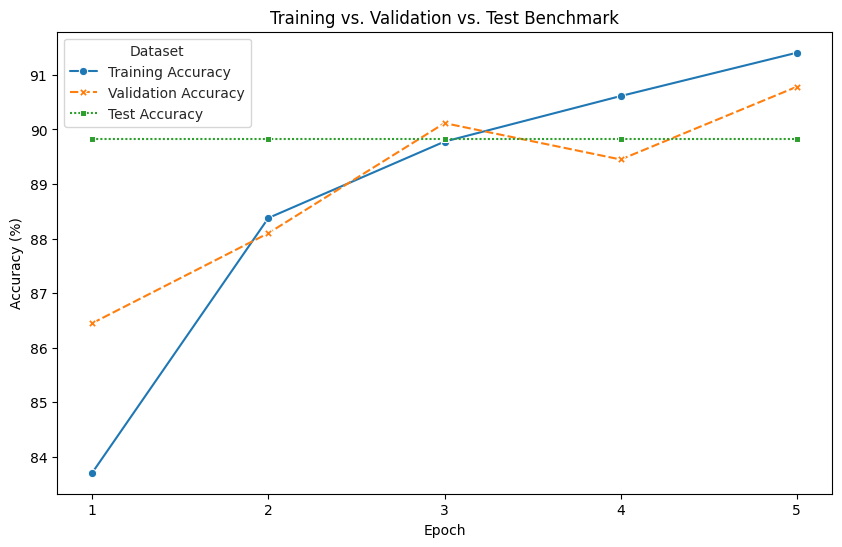

In [ ]:
# Plot all accuracies
def plot_accuracies(training_history, test_accuracy):
  data, epochs = prepare_data_to_plot(training_history, test_accuracy)

  plt.figure(figsize=(10, 6))
  plt.xlabel('Epoch')
  plt.xticks(epochs)
  plt.ylabel('Accuracy (%)')
  plt.title('Training vs. Validation vs. Test Benchmark')
  sns.set_style("whitegrid")

  sns.lineplot(data=data, x='Epoch', y='Accuracy', hue='Dataset', style='Dataset', markers=True)

  plt.show()

plot_accuracies(baseline_cnn_training_history, baseline_test_acc)

#**<font color='red'>5.</font> Improve the baseline CNN model**

##**<font color=red>Experiment 1</font> - Increase number of filters**

Double the numer of filters in the convolutional layer

In [ ]:
# Define the experimental CNN model
cnn_filters = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn_filters.summary()

# Compile the model
cnn_filters.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training/fitting the model
# using training datsets
cnn_filters_training_history = cnn_filters.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       173,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,738 (678.66 KB)

 Trainable params: 173,738 (678.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8353 - loss: 0.4687 - val_accuracy: 0.8758 - val_loss: 0.3482
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8874 - loss: 0.3172 - val_accuracy: 0.8932 - val_loss: 0.2981
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9011 - loss: 0.2768 - val_accuracy: 0.9002 - val_loss: 0.2736
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9108 - loss: 0.2484 - val_accuracy: 0.8967 - val_loss: 0.2860
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9170 - loss: 0.2274 - val_accuracy: 0.9058 - val_loss: 0.2633


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8996 - loss: 0.2740
Test accuracy: 0.8996000289916992


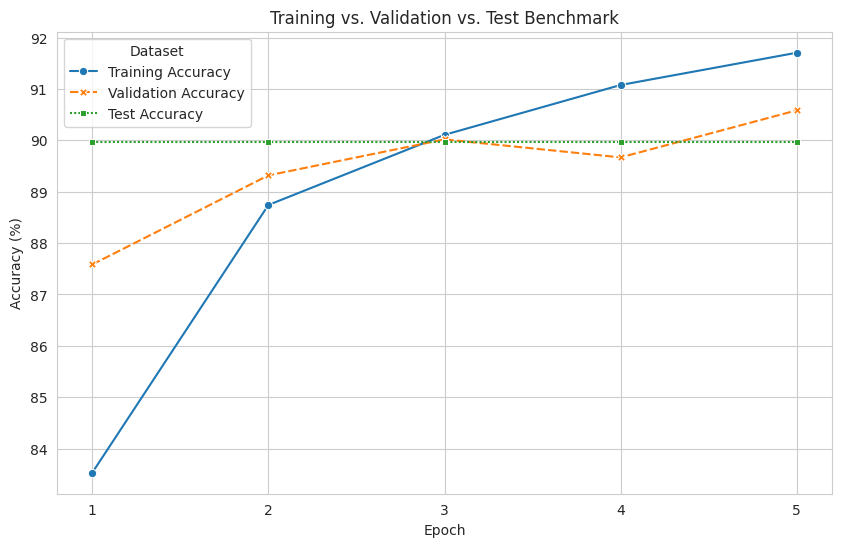

In [ ]:
cnn_filters_test_loss, cnn_filters_test_acc = cnn_filters.evaluate(X_test, y_test)
print("Test accuracy:", cnn_filters_test_acc)

plot_accuracies(cnn_filters_training_history, cnn_filters_test_acc)

###**Observation**



* Doubling filters (16 to 32) provided a very minor boost to test accuracy

* The training and validation curves stayed close, indicating no significant overfitting

* The improvement has mostly come because of the doubling of trainable parameters (because of doubling of the number of filters in the convolutional layer)



##**<font color=red>Experiment 2</font> - Increase number of convolution layers**

In [ ]:
# Define the experimental CNN model
cnn_conv = models.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn_conv.summary()

# Compile the model
cnn_conv.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training/fitting the model
# using training datsets
cnn_conv_training_history = cnn_conv.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │       123,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,066 (504.16 KB)

 Trainable params: 129,066 (504.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8364 - loss: 0.4617 - val_accuracy: 0.8757 - val_loss: 0.3366
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.8899 - loss: 0.3074 - val_accuracy: 0.8977 - val_loss: 0.2852
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9059 - loss: 0.2599 - val_accuracy: 0.9048 - val_loss: 0.2655
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9175 - loss: 0.2287 - val_accuracy: 0.9105 - val_loss: 0.2477
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9252 - loss: 0.2041 - val_accuracy: 0.9095 - val_loss: 0.2562


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9014 - loss: 0.2736
Test accuracy: 0.9014000296592712


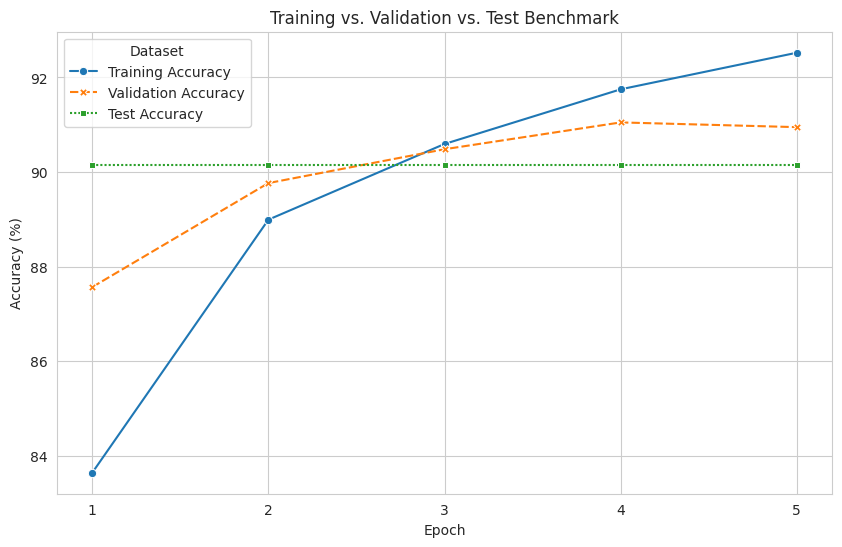

In [ ]:
cnn_conv_test_loss, cnn_conv_test_acc = cnn_conv.evaluate(X_test, y_test)
print("Test accuracy:", cnn_conv_test_acc)

plot_accuracies(cnn_conv_training_history, cnn_conv_test_acc)

### **Observation**

* Addition of a new convolution layer showed a more noticeable jump in accuracy as the new convolutional layer enables the model to learn more complex / hierarchial features

* There are signs of overfitting as the gap between training and validation accuracies started widening

* This shows the need for regularization to prevent overfitting.

##**<font color=red>Experiment 3</font> - Increase number of convolution layers with regularization (dropout)** *italicised text*

In [ ]:
# Define the experimental CNN model
cnn_dropout = models.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn_dropout.summary()

# Compile the model
cnn_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training/fitting the model
# using training datsets
cnn_dropout_training_history = cnn_dropout.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │       123,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,066 (504.16 KB)

 Trainable params: 129,066 (504.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.7464 - loss: 0.6948 - val_accuracy: 0.8575 - val_loss: 0.3859
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.8238 - loss: 0.4828 - val_accuracy: 0.8812 - val_loss: 0.3256
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8441 - loss: 0.4244 - val_accuracy: 0.8938 - val_loss: 0.2913
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8574 - loss: 0.3851 - val_accuracy: 0.9000 - val_loss: 0.2721
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8663 - loss: 0.3617 - val_accuracy: 0.9005 - val_loss: 0.2683


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8990 - loss: 0.2890
Test accuracy: 0.8989999890327454


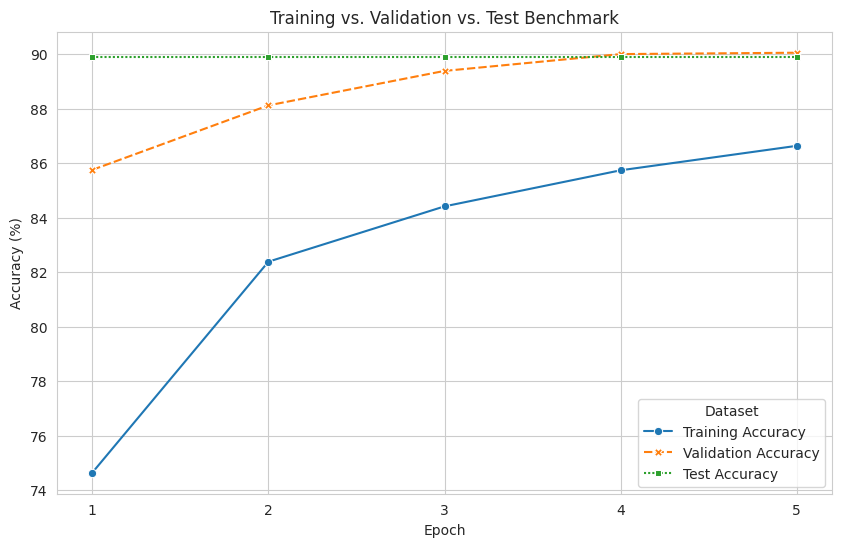

In [ ]:
cnn_dropout_test_loss, cnn_dropout_test_acc = cnn_dropout.evaluate(X_test, y_test)
print("Test accuracy:", cnn_dropout_test_acc)

plot_accuracies(cnn_dropout_training_history, cnn_dropout_test_acc)

###**Observation**



*   While the absolute test accuracy might be similar to Experiment 2, the gap between the training and validation accuracies narrowed down

*   This indicates that Dropout (0.3) successfully acted as a regularizer, making the model more robust



##**<font color=red>Experiment 4</font> - Increase number of neurons in the dense layer**

In [ ]:
# Define the experimental CNN model
cnn_dense = models.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn_dense.summary()

# Compile the model
cnn_dense.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training/fitting the model
# using training datsets
cnn_dense_training_history = cnn_dense.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8135 - loss: 0.5275 - val_accuracy: 0.8833 - val_loss: 0.3310
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8769 - loss: 0.3492 - val_accuracy: 0.8903 - val_loss: 0.3022
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.8891 - loss: 0.3083 - val_accuracy: 0.9017 - val_loss: 0.2734
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8987 - loss: 0.2808 - val_accuracy: 0.9043 - val_loss: 0.2632
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9032 - loss: 0.2629 - val_accuracy: 0.9018 - val_loss: 0.2767


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8955 - loss: 0.2861
Test accuracy: 0.8955000042915344


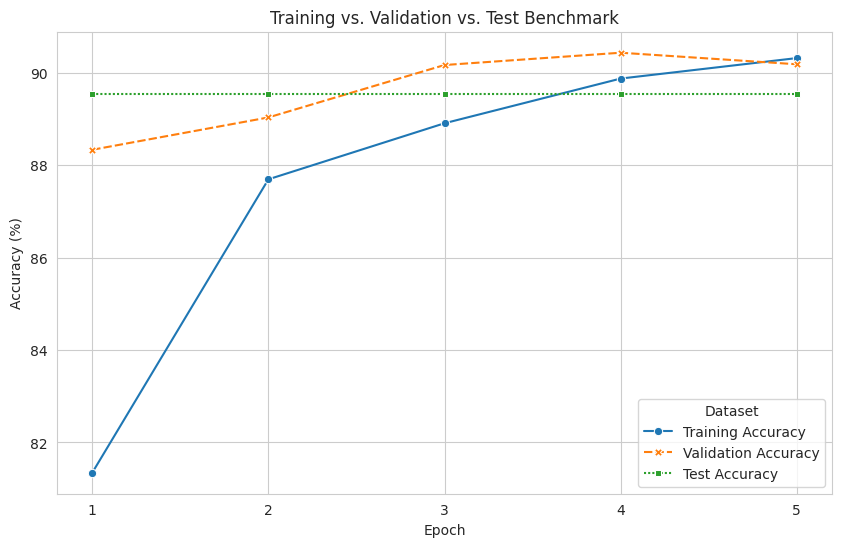

In [ ]:
cnn_dense_test_loss, cnn_dense_test_acc = cnn_dense.evaluate(X_test, y_test)
print("Test accuracy:", cnn_dense_test_acc)

plot_accuracies(cnn_dense_training_history, cnn_dense_test_acc)

### **Observation**



*   This experiment (64 units + dropout) actually performed slightly lower on the test set than the multi-layer CNN

*   This suggests that for image data, adding depth to the convolutional part is more effective than just making the fully connected (dense) part wider



##**<font color=red>Experiment 5</font> - Combination**

In [ ]:
# Define the experimental CNN model
cnn_combination = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Summarize the architecture of the CNN
cnn_combination.summary()

# Compile the model
cnn_combination.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training/fitting the model
# using training datsets
cnn_combination_training_history = cnn_combination.fit(X_train, y_train,
                  epochs=5,
                  validation_split=0.1
)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,146 (1.97 MB)

 Trainable params: 515,146 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.8152 - loss: 0.5124 - val_accuracy: 0.8745 - val_loss: 0.3313
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.8821 - loss: 0.3279 - val_accuracy: 0.8982 - val_loss: 0.2781
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.8986 - loss: 0.2762 - val_accuracy: 0.9090 - val_loss: 0.2450
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9104 - loss: 0.2421 - val_accuracy: 0.9107 - val_loss: 0.2509
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9212 - loss: 0.2141 - val_accuracy: 0.9107 - val_loss: 0.2460


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9097 - loss: 0.2470
Test accuracy: 0.9096999764442444


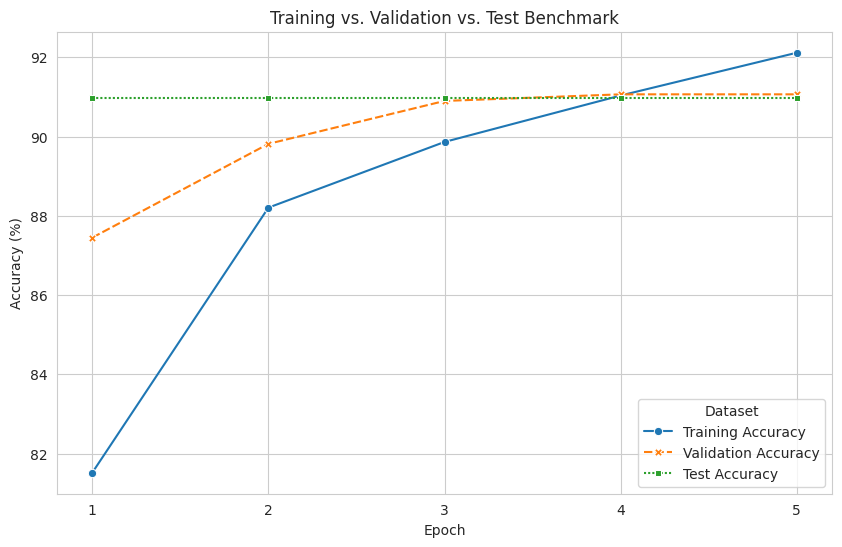

In [ ]:
cnn_combination_test_loss, cnn_combination_test_acc = cnn_combination.evaluate(X_test, y_test)
print("Test accuracy:", cnn_combination_test_acc)

plot_accuracies(cnn_combination_training_history, cnn_combination_test_acc)

### **Observation**



*   Combining a deeper feature extractor (two Conv layers) with a wider classifier (64 dense units) and regularization (Dropout) allows the model to capture complex patterns while maintaining generalization

*   Accuracy curves look the most stable with the model

